In [ ]:
#Telecon Churn Analysis

In [3]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Loading Dataset

df = pd.read_csv("../data/telecom_customer_churn.csv")

In [ ]:
#Understanding the dataset

In [8]:
df.shape

(7043, 21)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [14]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [17]:
df["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [ ]:
#Data Cleaning

In [18]:
df[df['TotalCharges']==' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [65]:
#Converts to numeric
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [20]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [21]:
df.dropna(inplace=True)

In [ ]:
#Exploratory data analysis

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [23]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [24]:
df.drop("customerID",axis=1,inplace=True)

In [25]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [26]:
df.shape

(7032, 20)

In [27]:
import seaborn as sns

Text(0, 0.5, 'no. of customers')

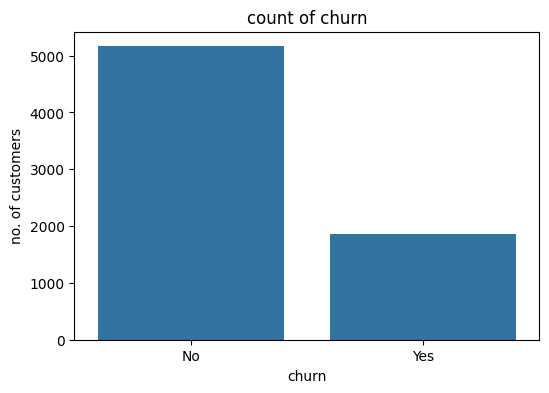

In [66]:
#Churn count
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Churn")
plt.title("count of churn")
plt.xlabel("churn")
plt.ylabel("no. of customers")

Text(0, 0.5, 'no. of customers')

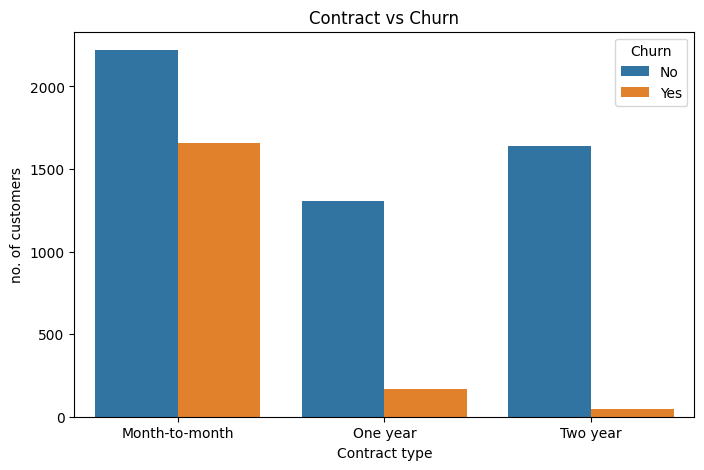

In [67]:
#Understanding influence of contract and churn
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract",hue="Churn")
plt.title("Contract vs Churn")
plt.xlabel("Contract type")
plt.ylabel("no. of customers")

In [28]:
contract_churn = (
    df.groupby("Contract")["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

contract_churn

,Contract,Churn,Percentage
0,Month-to-month,No,57.290323
1,Month-to-month,Yes,42.709677
2,One year,No,88.722826
3,One year,Yes,11.277174
4,Two year,No,97.151335
5,Two year,Yes,2.848665


Text(0, 0.5, 'tenure(months)')

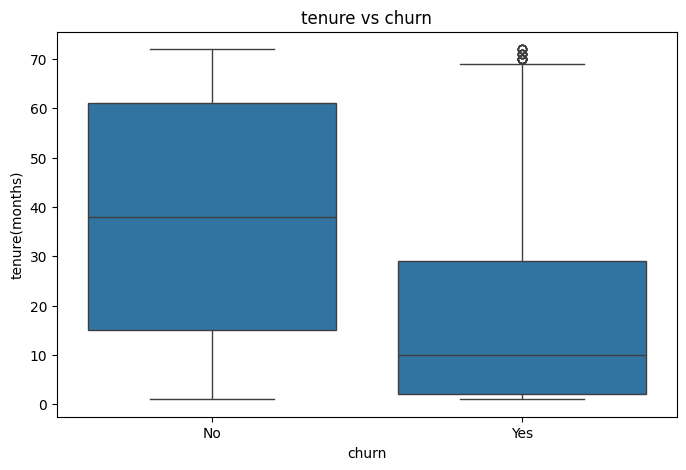

In [29]:
#Understanding influence of tenure and churn

plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Churn",y="tenure")
plt.title("tenure vs churn")
plt.xlabel("churn")
plt.ylabel("tenure(months)")

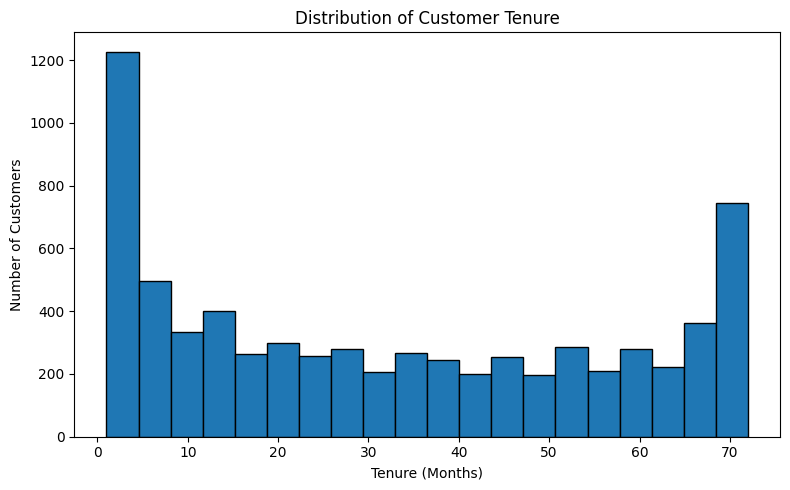

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["tenure"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig("tenure_histogram.png", dpi=300)

plt.show()

Text(0, 0.5, 'churn')

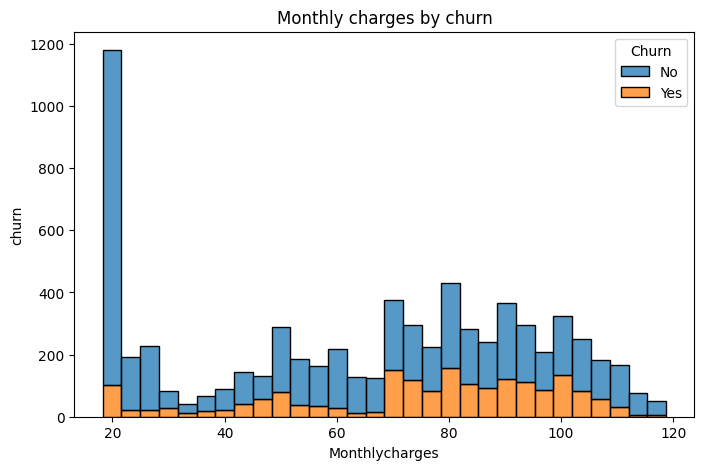

In [68]:
#Understanding influence of monthlychargesand churn

plt.figure(figsize=(8,5))
sns.histplot(
    data=df,x="MonthlyCharges",hue="Churn",bins=30,multiple="stack"
)
plt.title("Monthly charges by churn")
plt.xlabel("Monthlycharges")
plt.ylabel("churn")

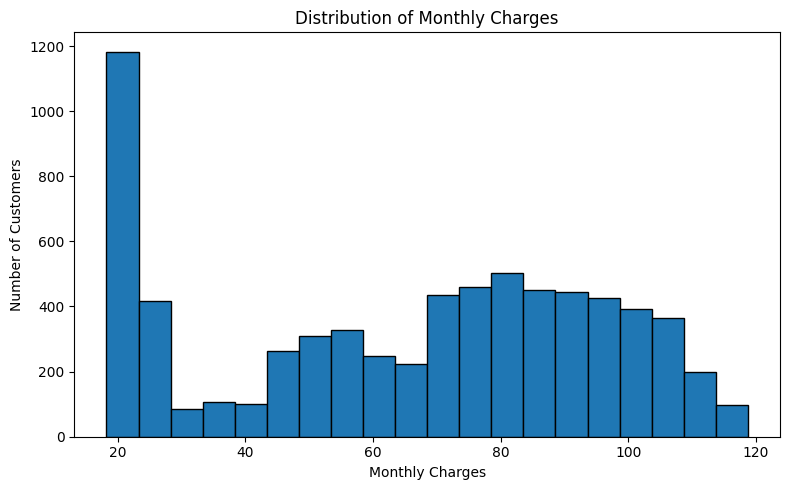

In [78]:
plt.figure(figsize=(8,5))

plt.hist(
    df["MonthlyCharges"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig("monthly_charge_histogram.png", dpi=300)

plt.show()

Text(0, 0.5, 'no. of customers')

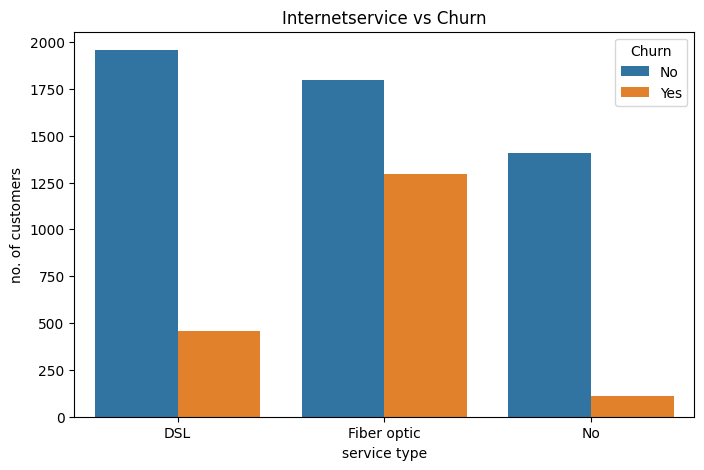

In [31]:
#Understanding influence of type of internet serive and churn

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="InternetService",hue="Churn")
plt.title("Internetservice vs Churn")
plt.xlabel("service type")
plt.ylabel("no. of customers")

In [32]:
service_churn = (
    df.groupby("InternetService")["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

service_churn

,InternetService,Churn,Percentage
0,DSL,No,81.001656
1,DSL,Yes,18.998344
2,Fiber optic,No,58.107235
3,Fiber optic,Yes,41.892765
4,No,No,92.565789
5,No,Yes,7.434211


Text(0, 0.5, 'no. of customers')

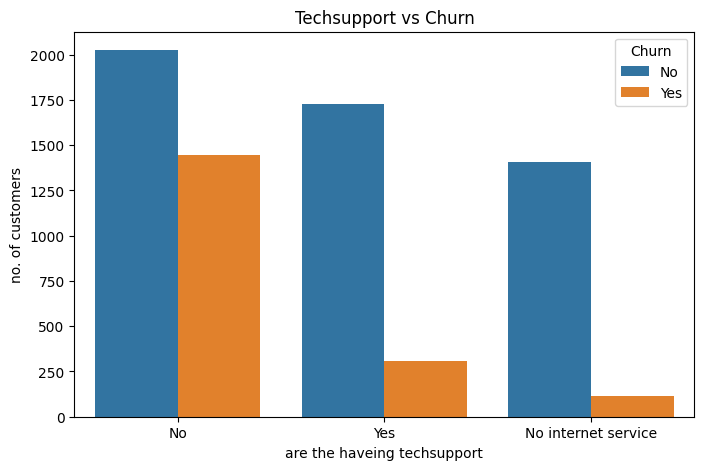

In [33]:
#Understanding influence of Techsupport over churn

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="TechSupport",hue="Churn")
plt.title("Techsupport vs Churn")
plt.xlabel("are the haveing techsupport")
plt.ylabel("no. of customers")

In [34]:
Techsupport_churn = (
    df.groupby("TechSupport")["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

Techsupport_churn

,TechSupport,Churn,Percentage
0,No,No,58.352535
1,No,Yes,41.647465
2,No internet service,No,92.565789
3,No internet service,Yes,7.434211
4,Yes,No,84.803922
5,Yes,Yes,15.196078


Text(0, 0.5, 'no. of customers')

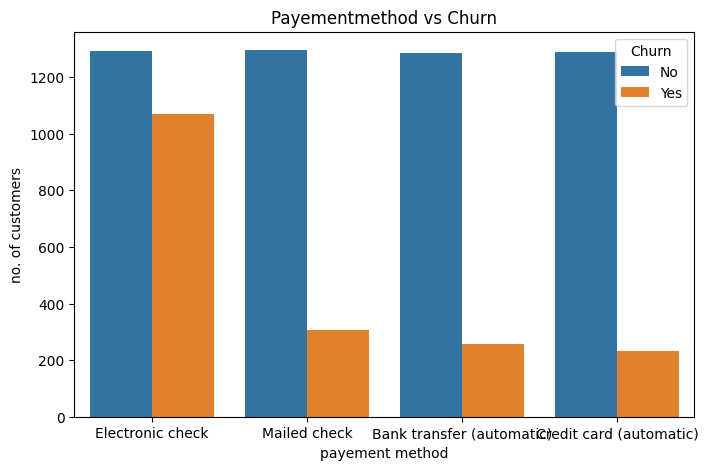

In [35]:
#Understanding influence of payment method over churn

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="PaymentMethod",hue="Churn")
plt.title("Payementmethod vs Churn")
plt.xlabel("payement method")
plt.ylabel("no. of customers")

In [37]:
PaymentMethod_churn = (
    df.groupby("PaymentMethod")["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

PaymentMethod_churn

,PaymentMethod,Churn,Percentage
0,Bank transfer (automatic),No,83.268482
1,Bank transfer (automatic),Yes,16.731518
2,Credit card (automatic),No,84.746877
3,Credit card (automatic),Yes,15.253123
4,Electronic check,No,54.714588
5,Electronic check,Yes,45.285412
6,Mailed check,No,80.798005
7,Mailed check,Yes,19.201995


Text(0, 0.5, 'no. of customers')

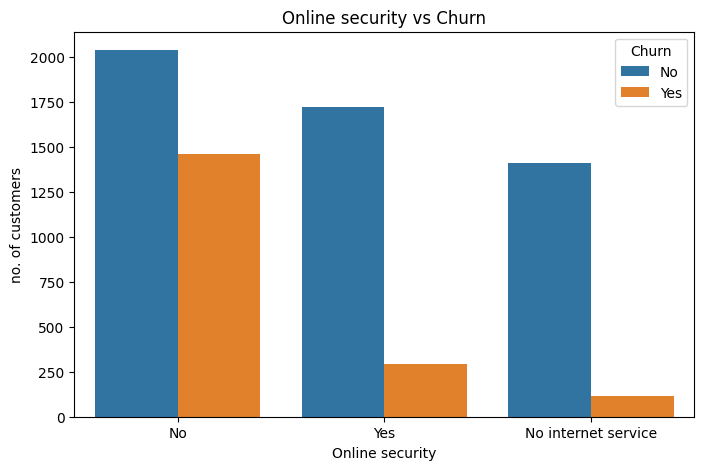

In [38]:
#Understanding influence of online security over churn

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="OnlineSecurity",hue="Churn")
plt.title("Online security vs Churn")
plt.xlabel("Online security")
plt.ylabel("no. of customers")

In [40]:
PaymentMethod_churn = (
    df.groupby("OnlineSecurity")["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

PaymentMethod_churn

,OnlineSecurity,Churn,Percentage
0,No,No,58.221333
1,No,Yes,41.778667
2,No internet service,No,92.565789
3,No internet service,Yes,7.434211
4,Yes,No,85.359801
5,Yes,Yes,14.640199


Text(0, 0.5, 'no. of customers')

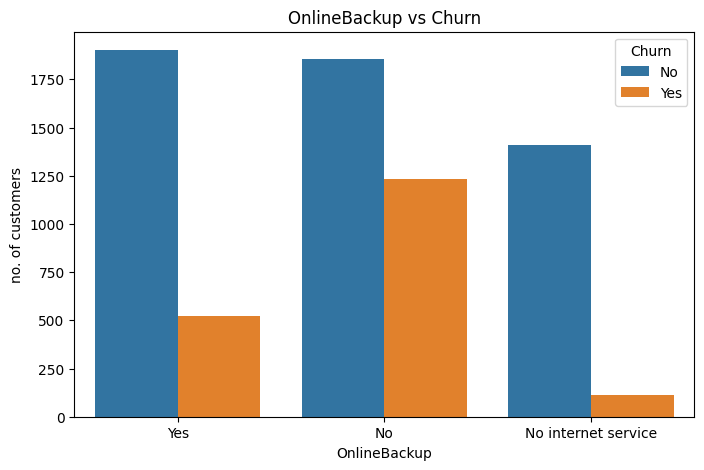

In [41]:
#Understanding influence of online backup over churn

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="OnlineBackup",hue="Churn")
plt.title("OnlineBackup vs Churn")
plt.xlabel("OnlineBackup")
plt.ylabel("no. of customers")

In [43]:
OnlineBackup_churn = (
    df.groupby("OnlineBackup")["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

OnlineBackup_churn

,OnlineBackup,Churn,Percentage
0,No,No,60.058309
1,No,Yes,39.941691
2,No internet service,No,92.565789
3,No internet service,Yes,7.434211
4,Yes,No,78.432990
5,Yes,Yes,21.567010


Text(0, 0.5, 'no. of customers')

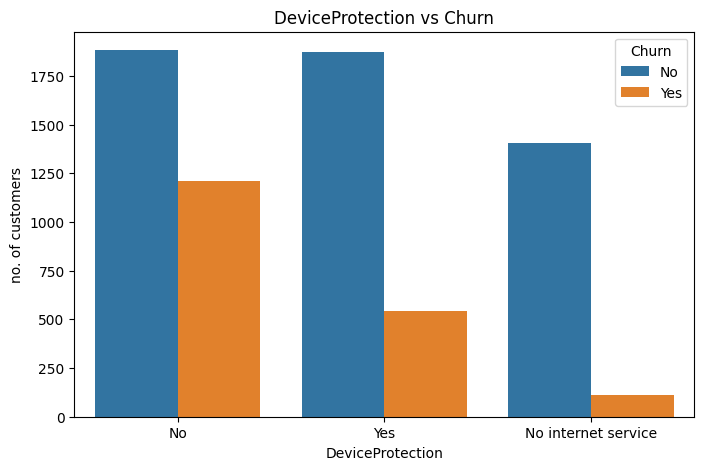

In [44]:
#Understanding influence of device protection over churn

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="DeviceProtection",hue="Churn")
plt.title("DeviceProtection vs Churn")
plt.xlabel("DeviceProtection")
plt.ylabel("no. of customers")

In [46]:
DeviceProtection_churn = (
    df.groupby("DeviceProtection")["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

DeviceProtection_churn

,DeviceProtection,Churn,Percentage
0,No,No,60.859729
1,No,Yes,39.140271
2,No internet service,No,92.565789
3,No internet service,Yes,7.434211
4,Yes,No,77.460711
5,Yes,Yes,22.539289


Text(0, 0.5, 'no. of customers')

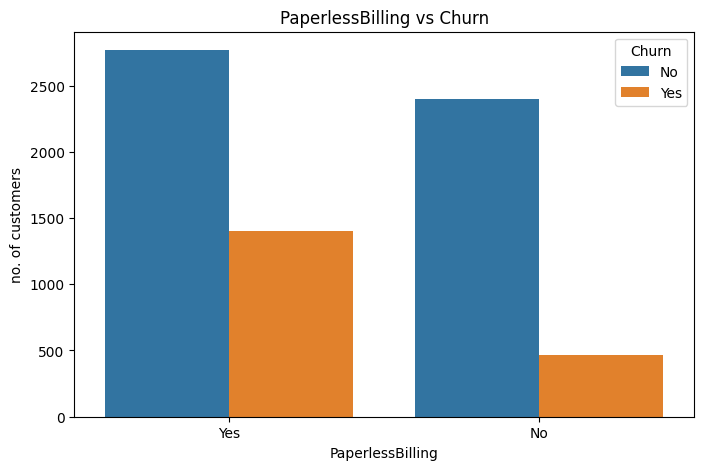

In [47]:
#Understanding influence of paperless billing over churn

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="PaperlessBilling",hue="Churn")
plt.title("PaperlessBilling vs Churn")
plt.xlabel("PaperlessBilling")
plt.ylabel("no. of customers")

In [48]:
PaperlessBilling_churn = (
    df.groupby("PaperlessBilling")["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

PaperlessBilling_churn

,PaperlessBilling,Churn,Percentage
0,No,No,83.624302
1,No,Yes,16.375698
2,Yes,No,66.410749
3,Yes,Yes,33.589251


Text(0, 0.5, 'no. of customers')

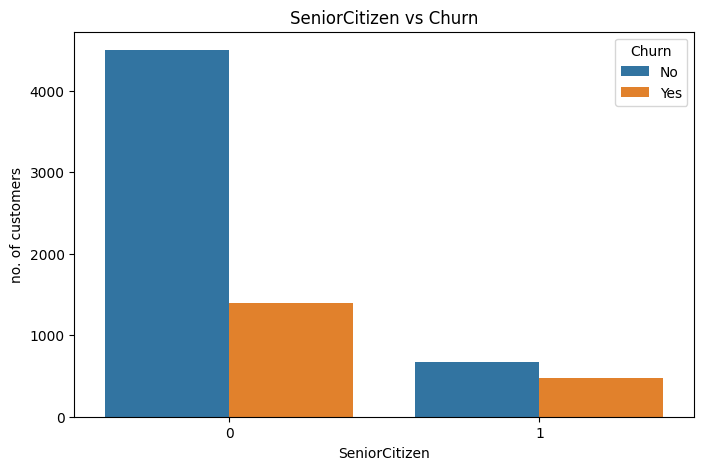

In [49]:
#Understanding influence of senior citizen over churn

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="SeniorCitizen",hue="Churn")
plt.title("SeniorCitizen vs Churn")
plt.xlabel("SeniorCitizen")
plt.ylabel("no. of customers")

In [50]:
SeniorCitizen_churn = (
    df.groupby("SeniorCitizen")["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

SeniorCitizen_churn

,SeniorCitizen,Churn,Percentage
0,0,No,76.349745
1,0,Yes,23.650255
2,1,No,58.318739
3,1,Yes,41.681261


In [ ]:
# ## Key Findings

# • Approximately 26.5% of customers churned.

# • Month-to-month customers had the highest churn rate.

# • Customers with lower tenure were more likely to leave.

# • Higher monthly charges were associated with increased churn.

# • Customers using Fiber Optic internet exhibited the highest churn among internet service users.

# • Customers without Technical Support, Online Security, Online Backup, and Device Protection consistently showed higher churn.

# • Electronic Check users had the highest churn among all payment methods.

# • Senior citizens exhibited a higher churn rate than non-senior customers.

# Overall, customers with fewer value-added services and flexible contracts showed the highest likelihood of churning.

# Recommendations

# • Promote long-term contracts.
# • Strengthen customer onboarding during the first 30 months.
# • Improve technical support quality.
# • Offer loyalty benefits for high-value customers.
# • Encourage automatic payment methods.

In [ ]:
#Feature engineering(preprocessing)

In [29]:
for col in df.columns:
    print(col, df[col].nunique())

gender 2
SeniorCitizen 2
Partner 2
Dependents 2
tenure 72
PhoneService 2
MultipleLines 3
InternetService 3
OnlineSecurity 3
OnlineBackup 3
DeviceProtection 3
TechSupport 3
StreamingTV 3
StreamingMovies 3
Contract 3
PaperlessBilling 2
PaymentMethod 4
MonthlyCharges 1584
TotalCharges 6530
Churn 2


In [70]:
#Seperating churn column and others
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [69]:
#Encoding the columns
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)
X=pd.get_dummies(
    X,drop_first=True
)

In [34]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [39]:
#Splitting dataset for training and testing
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

In [ ]:
#Training with ML models and comparing them

In [40]:
#Random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred = rf.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

Accuracy: 0.7867803837953091


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[917 116]
 [184 190]]


In [45]:
from sklearn.metrics import roc_auc_score

prob = rf.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, prob)

print("ROC-AUC:", roc)

ROC-AUC: 0.8180808713523251


In [71]:
#Results
print("Accuracy :", accuracy_score(y_test, pred))

print()

print(classification_report(y_test, pred))

print()

print(confusion_matrix(y_test, pred))

print()

print("ROC-AUC :", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Accuracy : 0.7867803837953091

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


[[917 116]
 [184 190]]

ROC-AUC : 0.8180808713523251


In [72]:
#Feature importance in random forest
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,TotalCharges,0.194313
1,tenure,0.168529
2,MonthlyCharges,0.167972
10,InternetService_Fiber optic,0.038913
28,PaymentMethod_Electronic check,0.037898
25,Contract_Two year,0.031862
4,gender_Male,0.028939
13,OnlineSecurity_Yes,0.027288
26,PaperlessBilling_Yes,0.025595
5,Partner_Yes,0.023280


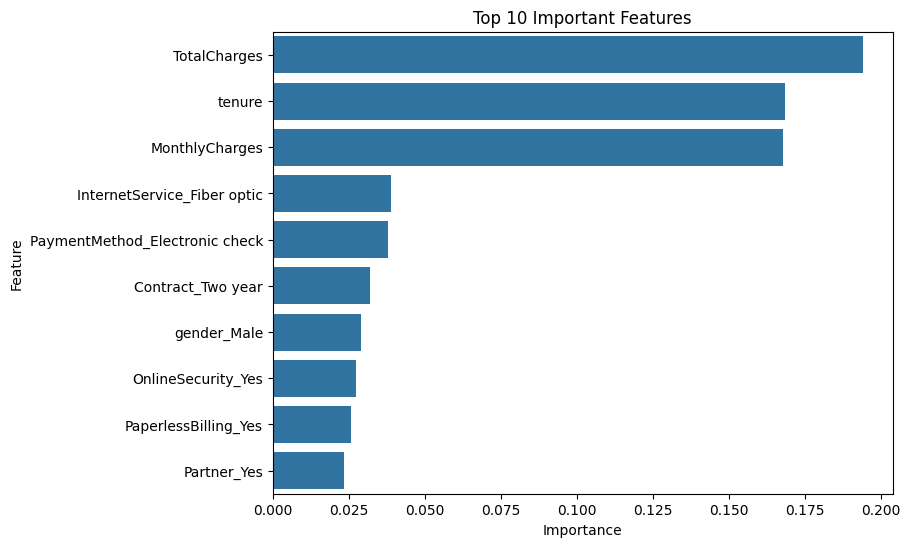

In [48]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [49]:
#XGBoost
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
xgb.fit(
    X_train,y_train
)
xgb_pred=xgb.predict(X_test)

In [56]:
#Results
print("Accuracy_xgb:",accuracy_score(y_test,xgb_pred))
print(classification_report(y_test,xgb_pred))
print(confusion_matrix(y_test,xgb_pred))
prob_xgb=xgb.predict_proba(X_test)[:,1]
roc_xgb=roc_auc_score(y_test,prob)
print("ROC_AUC",roc_xgb)

Accuracy_xgb: 0.7803837953091685
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1033
           1       0.60      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407

[[902 131]
 [178 196]]
ROC_AUC 0.8180808713523251


In [58]:
#LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)
prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print("Accuracy :", accuracy_score(y_test, pred_lr))
print()

print(classification_report(y_test, pred_lr))
print()

print(confusion_matrix(y_test, pred_lr))
print()

print("ROC-AUC :", roc_auc_score(y_test, prob_lr))

Accuracy : 0.8038379530916845

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


[[916 117]
 [159 215]]

ROC-AUC : 0.8356727976766699


In [73]:
#Logistic regression coefficients
coef = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_[0]
})

coef = coef.sort_values(by="Coefficient", ascending=False)

coef.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,0.727745
3,TotalCharges,0.639028
21,StreamingTV_Yes,0.249702
23,StreamingMovies_Yes,0.236368
9,MultipleLines_Yes,0.214359
28,PaymentMethod_Electronic check,0.181473
26,PaperlessBilling_Yes,0.142663
0,SeniorCitizen,0.070792
17,DeviceProtection_Yes,0.068965
29,PaymentMethod_Mailed check,0.033392


In [74]:
coef.tail(10)

,Feature,Coefficient
18,TechSupport_No internet service,-0.088138
16,DeviceProtection_No internet service,-0.088138
22,StreamingMovies_No internet service,-0.088138
6,Dependents_Yes,-0.105956
19,TechSupport_Yes,-0.118240
13,OnlineSecurity_Yes,-0.136804
24,Contract_One year,-0.310898
25,Contract_Two year,-0.602591
2,MonthlyCharges,-0.851551
1,tenure,-1.347613


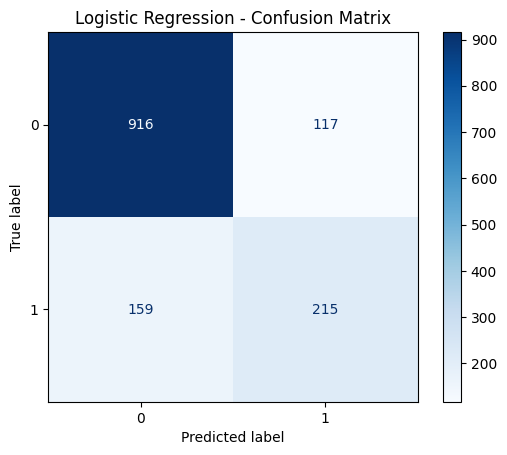

In [75]:
#Confusion matrix for logistic regression
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()


In [59]:
#DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

prob_dt = dt.predict_proba(X_test)[:,1]

In [60]:
#Results
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, pred_dt))

print()

print(classification_report(y_test, pred_dt))

print()

print(confusion_matrix(y_test, pred_dt))

print()

print("ROC-AUC :", roc_auc_score(y_test, prob_dt))

Accuracy : 0.7782515991471215

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407


[[872 161]
 [151 223]]

ROC-AUC : 0.8195096572466881


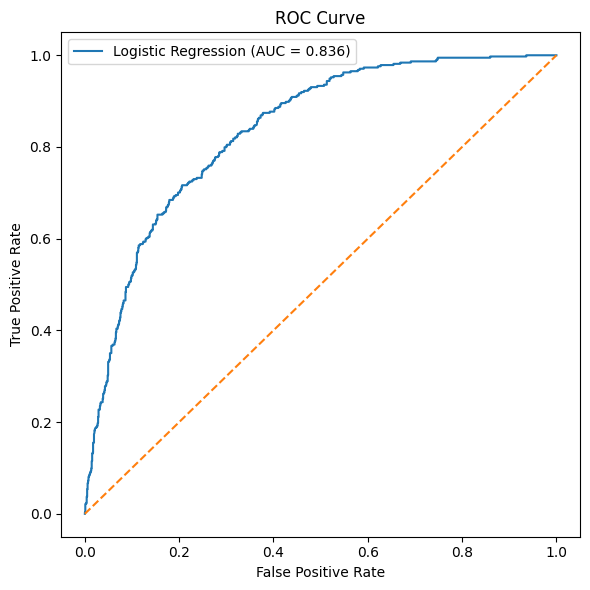

In [79]:
#roc_curve_visualisation
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig("roc_curve.png", dpi=300)

plt.show()

In [63]:
#crossvalidation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation Accuracy:", scores)
print("Mean Accuracy:", scores.mean())

Cross-validation Accuracy: [0.78666667 0.82044444 0.80533333 0.79111111 0.80888889]
Mean Accuracy: 0.802488888888889


In [ ]:
# Telecom Customer Churn Analysis and Prediction

# Project Overview

# Customer churn is one of the most important business challenges for subscription-based companies. This project analyzes customer demographics, service usage, billing information, and contract details to identify factors contributing to customer churn and develops machine learning models capable of predicting whether a customer is likely to leave.

#  Objectives

# - Perform comprehensive Exploratory Data Analysis (EDA)
# - Identify factors affecting customer churn
# - Build predictive machine learning models
# - Compare multiple classification algorithms
# - Generate actionable business recommendations

# **Dataset:** IBM Telco Customer Churn Dataset

# **Tools Used:** Python, Pandas, NumPy, Matplotlib, Scikit-learn, XGBoost